## 💰 Forecasting Future Prices - Linear Regression

### 🎯 Objectives:
The goal of this lab is to apply `Linear Regression` to analyze the relationship between the selected features and the target variable.  
We will:
- Use multiple features (e.g., `Volume`, `Price_Change`, and `Close_Price`)  
- Train a linear regression model
- Calculate the mean squared error (MSE)
- Build a baseline model


### Import Libraries

In [2]:
import numpy as np
import pandas as pd

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split 
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

### 🔢 Generate Synthetic Data

In [4]:
# Number of rows
n = 50 

# Data Generation 
np.random.seed(42)  
volume = np.random.randint(9000, 15000, n) 
price_diff = np.round(np.random.uniform(-2, 2, n), 2) 
close_price = np.round(np.random.uniform(15, 30, n), 2)
next_price = np.round(close_price + price_diff, 2) 
buy = (next_price > close_price).astype(int) 

# DataFrame
df = pd.DataFrame({
    'Volume': volume,
    'Price_Change': price_diff,
    'Close_Price': close_price,
    'Next_Price': next_price,
    'Buy': buy
})
df.head()

,Volume,Price_Change,Close_Price,Next_Price,Buy
0,9860,1.86,19.66,21.52,1
1,14390,1.23,19.88,21.11,1
2,14226,-0.78,25.94,25.16,0
3,14191,-1.61,24.56,22.95,0
4,12772,0.74,28.31,29.05,1


Purpose:
Generate a synthetic financial dataset containing random stock volumes, price changes, and next-day prices.
Also create a binary target (Buy) indicating whether the next price increases.

### 🤖 Build Linear Regression Model - Predicting Next Price


In [5]:
# Train Linear Regression model and evaluate MSE
# Predicting Next Price using Linear Regression

X = df[['Volume', 'Price_Change', 'Close_Price']] 
y_price = df['Next_Price']

X_train, X_test, y_train, y_test = train_test_split(X, y_price, test_size= 0.2, random_state=42) 
 
linear_model = LinearRegression() 
linear_model.fit(X_train, y_train) 

y_pred_linear = linear_model.predict(X_test) 

mse = mean_squared_error(y_test, y_pred_linear) 
print("Linear Regression MSE:", mse)  

Linear Regression MSE: 7.348993262278063e-23


Purpose:
Train a linear regression model to predict the next price using trading volume, price change, and current price.
Model performance is evaluated using Mean Squared Error (MSE).

### ⚙️ Build Baseline Model

In [6]:
# Calculate the baseline predictions (mean of the target)
baseline_pred = np.full_like(y_price, y_price.mean(), dtype=np.float64)
baseline_mes = mean_squared_error(y_price, baseline_pred) 

print("Baseline MSE (using mean target): " ,baseline_mes) 

Baseline MSE (using mean target):  18.371499999999997


Baseline Purpose:
Train a simple model that always predicts the most frequent value to serve as a reference point for performance comparison.
In our case, we use the average.
This helps evaluate whether a more complex model 🤖 actually performs better than simply guessing the most common outcome.

### 📊 Confusion Matrices & Evaluation

In [7]:
# Create actual and predicted labels
actual_increase = (y_test > X_test['Close_Price']).astype(int)
predicted_increase = (y_pred_linear > X_test['Close_Price']).astype(int) 

# Make confusion matrix to compare actual vs predicted increases
cm_model = confusion_matrix(actual_increase, predicted_increase) 

# For baseline model: predict the most common value (0 or 1) for all rows
from collections import Counter
most_common = Counter(actual_increase).most_common(1)[0][0]

# Create baseline predictions with the most common class
baseline_class_pred = np.full_like(actual_increase, fill_value=most_common) 

# Confusion matrix for baseline predictions
cm_baseline = confusion_matrix(actual_increase, baseline_class_pred)

We convert the continuous values into classes (0 and 1) so that we can use classification metrics like the confusion matrix to compare the models.

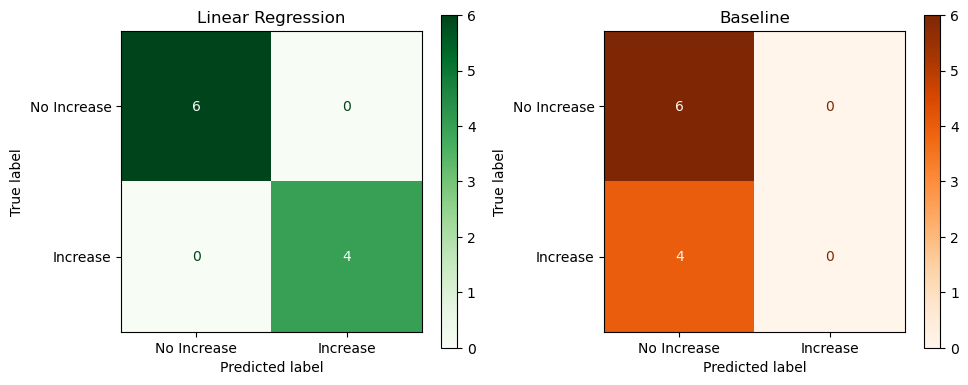

Linear Regression Classification:
✅ True Negatives (TN): 6
❌ False Positives (FP): 0
❌ False Negatives (FN): 0
✅ True Positives (TP): 4
--------------------------------------------------
Baseline Model:
✅ True Negatives (TN): 6
❌ False Positives (FP): 0
❌ False Negatives (FN): 4
✅ True Positives (TP): 0


In [8]:
# Plot both confusion matrices
fig, axs = plt.subplots(1, 2, figsize=(10, 4)) 

m_conf = ConfusionMatrixDisplay(cm_model, display_labels=["No Increase", "Increase"])
m_conf.plot(ax=axs[0], cmap='Greens')
axs[0].set_title('Linear Regression')

b_conf = ConfusionMatrixDisplay(cm_baseline, display_labels=["No Increase", "Increase"])
b_conf.plot(ax=axs[1], cmap='Oranges')
axs[1].set_title('Baseline')

plt.tight_layout()
plt.show()

# Print TN/FP/FN/TP values
tn, fp, fn, tp = cm_model.ravel() 
print("Linear Regression Classification:")
print("✅ True Negatives (TN):", tn)     
print("❌ False Positives (FP):", fp)    
print("❌ False Negatives (FN):", fn)    
print("✅ True Positives (TP):", tp)    
print('-' * 50)

tn, fp, fn, tp = cm_baseline.ravel()
print("Baseline Model:")
print("✅ True Negatives (TN):", tn)
print("❌ False Positives (FP):", fp)
print("❌ False Negatives (FN):", fn)
print("✅ True Positives (TP):", tp)

## Polynomial Regression - Evaluation and Visualization

### 🎯 Objectives:
Apply Polynomial regression to analyze the relationship between the selected features and the target variable.  
We will:
- Use the same features (e.g., `Volume`, `Price_Change`, and `Close_Price`)  
- Train a Polynomial regression model
- Calculate the mean squared error (MSE)
- Visualize the predictions to evaluate the model performance with different degree


### Import Libraries

In [9]:
from sklearn.preprocessing import PolynomialFeatures

### Build Linear Regression Model - with Polynomial Features

In [10]:
poly = PolynomialFeatures(degree=3) #Create polynomial features up to degree 3 
X_poly_train = poly.fit_transform(X_train) 
X_poly_test = poly.transform(X_test) 

# Train the model
model = LinearRegression() 
model.fit(X_poly_train, y_train) 

# Predict and calculate the error
y_pred = model.predict(X_poly_test)
mse = mean_squared_error(y_test, y_pred)
print("Polynomial Regression MSE:", mse)

Polynomial Regression MSE: 1.413963016555189e-13


### 📉 Visualization

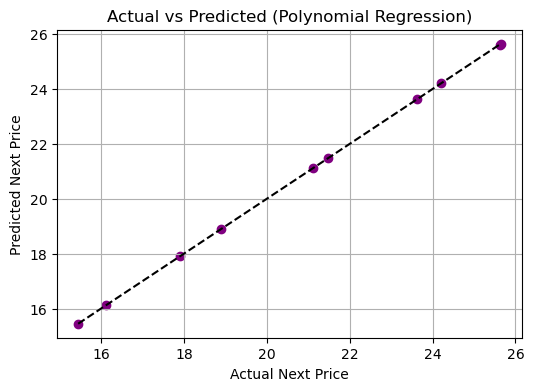

In [11]:
# Plotting Actual vs. Predicted values to evaluate the model performance
plt.figure(figsize=(6, 4))
plt.scatter(y_test, y_pred, color='purple')  
min_val, max_val = y_test.min(), y_test.max()
plt.plot([min_val, max_val], [min_val, max_val], color='black', linestyle='--')
plt.xlabel("Actual Next Price")
plt.ylabel("Predicted Next Price")
plt.title("Actual vs Predicted (Polynomial Regression)")
plt.grid(True)
plt.show()

Purpose:
Apply polynomial regression (degree 3) to capture nonlinear relationships in the data.
Then evaluate model performance using MSE and a scatter plot comparing predicted vs actual values.